# SWOT along-track SSH spectra in square boxes — Dask parallel version

This notebook is the same as **Regional_SSH_spectra_dask.ipynb** at global scale.
All loader and helper functions, and plotting cells are identical.

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# ── Dask ─────────────────────────────────────────────────────────────────────
import dask
import dask.bag as db
from dask.distributed import Client, LocalCluster, progress, wait

from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert, load_swot_l2_unsmoothed 

## 1. Configuration
Identical to GSER_SSH_spectra.ipynb — change only these values.

In [2]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'
#DATA_DIR    = '/Users/zoecas/Documents/data/'

# ── One sub-directory per month of SWOT data ────────────────────────────────
# Every file found under each entry is tagged with the (year, month) inferred
# from that sub-directory's name (see parse_year_month below).
DATA_SUBDIRS = ['SWOT_L2_LR_SSH_Expert_0124/',
                'SWOT_L2_LR_SSH_Expert_0224/',
                'SWOT_L2_LR_SSH_Expert_0324/',
               'SWOT_L2_LR_SSH_Expert_0424/',
               'SWOT_L2_LR_SSH_Expert_0524/',
               'SWOT_L2_LR_SSH_Expert_0624/',
               'SWOT_L2_LR_SSH_Expert_0724/',
               'SWOT_L2_LR_SSH_Expert_0824/',
               'SWOT_L2_LR_SSH_Expert_0924/',
               'SWOT_L2_LR_SSH_Expert_1024/',
               'SWOT_L2_LR_SSH_Expert_1124/',
               'SWOT_L2_LR_SSH_Expert_1224/',
               ]
FILE_PATTERN = 'SWOT_L2_LR_SSH_Expert_*.nc'

import re

def parse_year_month(subdir_name, overrides=None):
    """
    Infer (year, month) from a sub-directory name.

    Default rule: the trailing 4 digits are read as MMYY, e.g.
    'SWOT_L2_0225' -> month=2, year=2025.

    For directories that don't follow this convention, pass a dict via
    `overrides` mapping subdir name -> (year, month); it takes precedence
    over the automatic parsing.
    """
    if overrides and subdir_name in overrides:
        return overrides[subdir_name]
    name = subdir_name.rstrip('/').rstrip('\\')
    match = re.search(r'(\d{2})(\d{2})$', name)
    if not match:
        raise ValueError(
            f"Could not infer year/month from subdirectory name '{subdir_name}'. "
            f"Add an explicit entry to DATA_SUBDIR_OVERRIDES instead."
        )
    mm, yy = match.groups()
    month = int(mm)
    year = 2000 + int(yy)
    if not (1 <= month <= 12):
        raise ValueError(f"Parsed invalid month={month} from '{subdir_name}'.")
    return year, month

# Manual overrides for sub-directories that don't follow the MMYY naming
# convention above, e.g. {'my_weird_folder_name': (2025, 7)}
DATA_SUBDIR_OVERRIDES = {}

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 1000.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25
DETREND           = "constant"
SWH_VAR           = False
CROSS_TRACK_INTEGRATED = True
# ── Box size ──────────────────────────────────────────────────────────────────
BOX_DEG = 2.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = True   # add internal tide correction (height_cor_xover + internal_tide_hret)

# ── Dask cluster parameters ───────────────────────────────────────────────────
N_WORKERS          = 5       # number of worker processes
THREADS_PER_WORKER = 1       # do NOT increase, core functions contain lops
MEMORY_LIMIT       = '3GB'   # per worker RAM cap


## 2. Start the Dask cluster and open the Dashboard

**`LocalCluster`** spawns `N_WORKERS` independent Python processes on the same machine.

> Warning: keep `threads_per_worker=1`:
> the `swot_analysis` spectral loops are GIL-bound, and the underlying
> HDF5/netCDF4 library is not thread-safe for concurrent reads from the same
> process. Each worker uses one thread, and processes are isolated from one
> another, so there is no contention on either count.

In [3]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client   # displays the interactive widget in JupyterLab

/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 63834 instead
  warnings.warn(


Dashboard: http://127.0.0.1:63834/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:63834/status,
Dashboard: http://127.0.0.1:63834/status,Workers: 5
Total threads: 5,Total memory: 13.97 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:63835,Workers: 0
Dashboard: http://127.0.0.1:63834/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:63849,Total threads: 1
Dashboard: http://127.0.0.1:63854/status,Memory: 2.79 GiB
Nanny: tcp://127.0.0.1:63838,


## 3. Defining functions
Identical to GSER_SSH_spectra.ipynb (`segments_to_dataset`, `build_box_dataset`).

In [4]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset."""
    if not all_segments:
        raise ValueError('No segments to pack.')
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': 'Along-track SSH(A) PSD',
                  'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments],
                      {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments],
                     {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments],
                     {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments],
                      {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            granule=(['segment'], [s._granule for s in all_segments]),
            year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
                  {'long_name': 'Year of the source SWOT sub-directory'}),
            month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
                   {'long_name': 'Month of the source SWOT sub-directory'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        ),
    )


def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

## 4. Wrapping worker function

This is the work dispatched to each Dask worker. It is a plain Python
function ; Dask simply calls it in a worker process and
serialises the return value back to the scheduler. The return value is a small
list of `SegmentSpectrum` dataclasses so inter-process transfer
is fast regardless of how many workers are used.

Errors are caught and returned as `(filepath, error_string, None)` so one bad
granule never cancels the whole computation.

In [5]:
def process_one_file(filepath, ssh_var, hret,
                      segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max, swh_var, cross_track_integrated):
    """
    Dask worker task: load one Expert granule, compute spectra, filter to
    region of interest, return (granule_stem, list[SegmentSpectrum], wavenumber).
    On any error returns (filepath, error_string, None) with a full traceback
    so the cause is immediately visible in the gather cell.
    """
    import numpy as np
    import xarray as xr
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert
    from swot_analysis import compute_pass_spectra
    from pathlib import Path

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var, HRET=hret, swh_var=swh_var)
    except Exception:
        return (filepath, f'load error:\n{_tb.format_exc()}', None)

    try:
        result = compute_pass_spectra(
            ssha=data['ssha'],
            latitude=data['latitude'],
            longitude=data['longitude'],
            cross_track_distance=data['cross_track_distance'],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend,
            cross_track_integrated = cross_track_integrated
        )
    except Exception:
        return (filepath, f'spectra error:\n{_tb.format_exc()}', None)

    granule_name = Path(filepath).stem
    kept, wavenumber = [], None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                seg._granule = granule_name
                kept.append(seg)

    return (granule_name, kept, wavenumber)

## 5. Parallel processing with Dask

### How it works

```
filepaths  ──►  client.map(process_one_file, ...)  ──►  futures[]
                    │ dispatched to N_WORKERS processes
                    │ visible in Dashboard → Task Stream
                    ▼
             progress(futures)   ← live bar in notebook
             wait(futures)       ← block until all done
                    ▼
             gather results  ──►  flat list of SegmentSpectrum
```

### Dashboard tabs to watch
| Tab | What to watch |
|---|---|
| **Task Stream** | colour-coded bars: orange=load, blue=spectra; gaps = scheduler overhead |
| **Workers** | per-worker CPU (aim for ≥ 80%) and memory (watch for memory pressure) |
| **Progress** | overall fraction done |
| **Bytes stored** | amount of intermediate data held in worker memory — should stay low since results are small SegmentSpectrum objects |

> Open `http://localhost:8787` in a browser tab **before** running this cell.

In [ ]:
# Build the full file list across all monthly sub-directories, keeping a
# parallel list that tags every file with its (year, month).
filepaths = []
file_year_month = []

for subdir in DATA_SUBDIRS[:]:
    year, month = parse_year_month(subdir, overrides=DATA_SUBDIR_OVERRIDES)
    subdir_files = sorted(glob.glob(os.path.join(DATA_DIR, subdir, FILE_PATTERN)))
    print(f'{subdir:30s} -> {len(subdir_files):4d} files  (year={year}, month={month:02d})')
    filepaths.extend(subdir_files)
    file_year_month.extend([(year, month)] * len(subdir_files))

print(f'\n{len(filepaths)} Expert granule files found across {len(DATA_SUBDIRS)} sub-directories.')

import functools

worker_fn = functools.partial(
    process_one_file,
    ssh_var=SSH_VAR,
    hret=HRET,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
    detrend=DETREND,
    swh_var=SWH_VAR,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
    cross_track_integrated = CROSS_TRACK_INTEGRATED,
    
)

futures = client.map(worker_fn, filepaths)



# Live progress bar inside the notebook (also visible on the Dashboard)
#progress(futures)

# Block until all futures are complete
wait(futures)


SWOT_L2_LR_SSH_Expert_0124/    ->  865 files  (year=2024, month=01)
SWOT_L2_LR_SSH_Expert_0224/    ->  809 files  (year=2024, month=02)
SWOT_L2_LR_SSH_Expert_0324/    ->  857 files  (year=2024, month=03)
SWOT_L2_LR_SSH_Expert_0424/    ->  837 files  (year=2024, month=04)
SWOT_L2_LR_SSH_Expert_0524/    ->  860 files  (year=2024, month=05)
SWOT_L2_LR_SSH_Expert_0624/    ->  835 files  (year=2024, month=06)
SWOT_L2_LR_SSH_Expert_0724/    ->  859 files  (year=2024, month=07)
SWOT_L2_LR_SSH_Expert_0824/    ->  869 files  (year=2024, month=08)
SWOT_L2_LR_SSH_Expert_0924/    ->  834 files  (year=2024, month=09)
SWOT_L2_LR_SSH_Expert_1024/    ->  859 files  (year=2024, month=10)
SWOT_L2_LR_SSH_Expert_1124/    ->  835 files  (year=2024, month=11)
SWOT_L2_LR_SSH_Expert_1224/    ->  866 files  (year=2024, month=12)

10185 Expert granule files found across 12 sub-directories.


In [10]:
# Gather results back to the main process
raw_results = client.gather(futures)

all_segments, wavenumber, skipped = [], None, []

for item, (year, month) in zip(raw_results, file_year_month):
    name, payload, wk = item
    if isinstance(payload, str):                 # error string
        skipped.append((name, payload))
    else:
        for seg in payload:
            seg._year = year
            seg._month = month
        all_segments.extend(payload)
        if wavenumber is None and wk is not None:
            wavenumber = wk

print(f'\nDone. {len(all_segments)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')
if skipped:
    for name, err in skipped:
        print(f'  {name}: {err}')

# Sanity check: segment counts per (year, month)
from collections import Counter
month_counts = Counter((s._year, s._month) for s in all_segments)
print('\nSegments per (year, month):')
for (y, m), n in sorted(month_counts.items()):
    print(f'  {y}-{m:02d}: {n}')



Done. 29291 segments retained in region.
0 file(s) skipped.

Segments per (year, month):
  2024-01: 29291


## 6. Build segment and box datasets
Identical to GSER_SSH_spectra.ipynb from here onward.

In [11]:
if not all_segments:
    raise RuntimeError('No segments retained — check region bounds, '
                        'file pattern, and SSH variable name.')

ds_segments = segments_to_dataset(all_segments, wavenumber)
print(f'Segment dataset: {ds_segments.sizes}')

ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_fraction=0.15)
#ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')
ds_boxes

Segment dataset: Frozen({'segment': 29291, 'wavenumber': 251})
Box dataset: 6959 boxes with at least 1 segment


<xarray.Dataset> Size: 14MB
Dimensions:            (box: 6959, wavenumber: 251)
Coordinates:
  * box                (box) int64 56kB 0 1 2 3 4 5 ... 6954 6955 6956 6957 6958
  * wavenumber         (wavenumber) float64 2kB 0.0 0.0009994 ... 0.2489 0.2499
Data variables:
    mean_psd           (box, wavenumber) float64 14MB 0.04495 ... 1.536e-05
    n_segments         (box) int64 56kB 7 5 4 5 5 6 6 3 6 ... 6 3 4 3 3 5 2 6 6
    sampling_fraction  (box) float64 56kB 0.7778 0.5556 0.4444 ... 0.6667 0.6667
    lat_center         (box) float64 56kB -59.0 -59.0 -59.0 ... 59.0 59.0 59.0
    lon_center         (box) float64 56kB 5.0 7.0 9.0 11.0 ... 349.0 351.0 353.0
Attributes:
    box_size_deg:           2.0
    min_sampling_fraction:  0.15

## 7. Diagnostics — sanity check

In [12]:
print('Segments per swath:')
for sw in ('left', 'right'):
    n = int((ds_segments['swath'] == sw).sum())
    print(f'  {sw}: {n}')

unique_granules = len(np.unique(ds_segments['granule'].values))
print(f'Unique granules contributing segments: {unique_granules}')
print(f'Boxes with ≥  5 segments: {int((ds_boxes["n_segments"] >=  5).sum())}')
print(f'Boxes with ≥ 10 segments: {int((ds_boxes["n_segments"] >= 10).sum())}')
print(f'Max segments in a box:    {int(ds_boxes["n_segments"].max())}')

Segments per swath:
  left: 14619
  right: 14672
Unique granules contributing segments: 850
Boxes with ≥  5 segments: 2850
Boxes with ≥ 10 segments: 0
Max segments in a box:    9


In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker


def plot_box(var : np.array, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
             norm : norm = None, vmin : float = None, vmax : float = None
            ):

    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
            
        sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
    cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

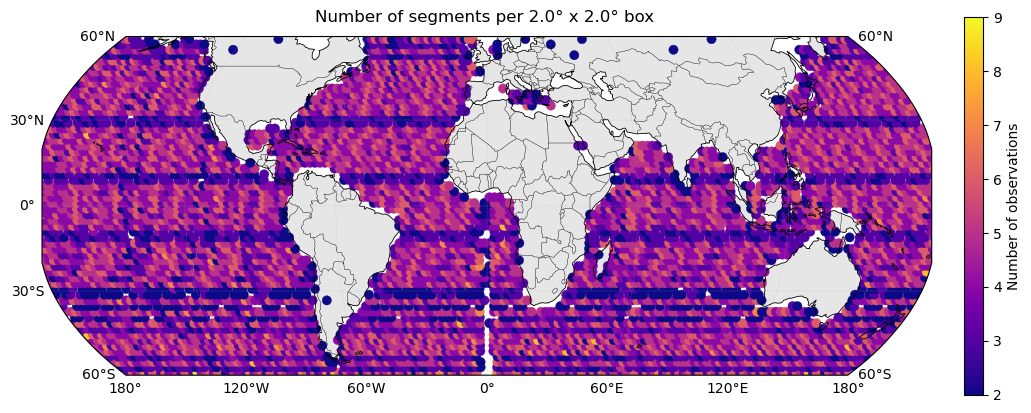

In [14]:
fig, ax = plot_box(ds_boxes["n_segments"].values,
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

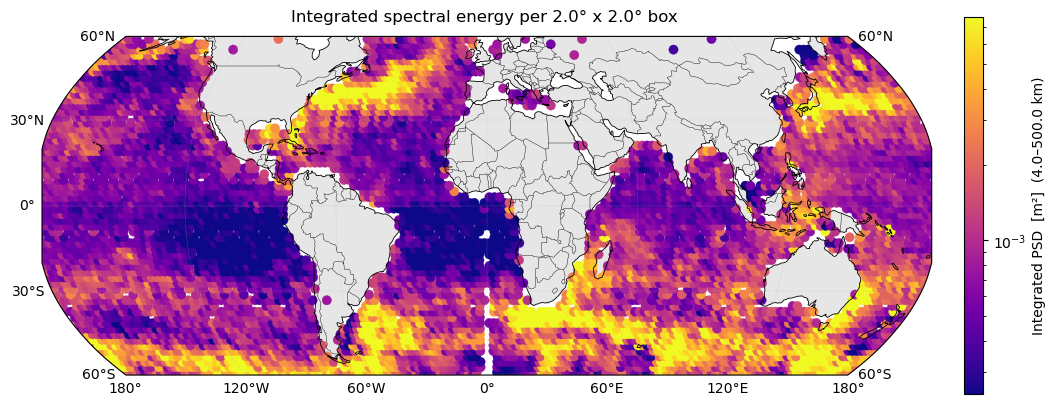

In [15]:
K_MIN, K_MAX = 1/500, 1/4
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_boxes["lon_center"].values,ds_boxes["lat_center"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

In [16]:
ds_january = build_box_dataset(ds_segments.where(ds_segments.month==3,drop=True), box_deg=BOX_DEG,min_sampling_fraction=0.15)

ValueError: zero-size array to reduction operation maximum which has no identity

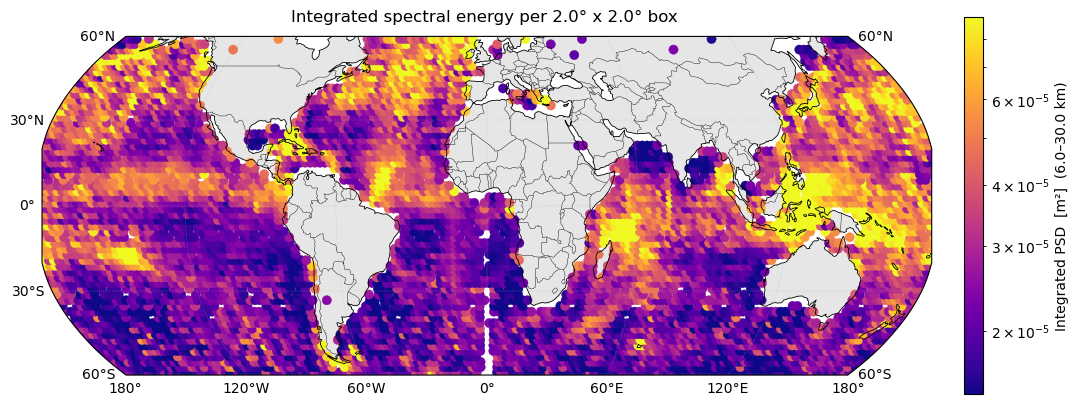

NameError: name 'ds_january' is not defined

In [17]:
K_MIN, K_MAX = 1/30, 1/6
k      = ds_boxes['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_boxes["lon_center"].values,ds_boxes["lat_center"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

K_MIN, K_MAX = 1/30, 1/6
k      = ds_january['wavenumber'].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_january['mean_psd'].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plot_box(energy,ds_january["lon_center"].values,ds_january["lat_center"].values,
                   cmap="plasma", title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   label=f'Integrated PSD  [m²]  ({1/K_MAX:.1f}–{1/K_MIN:.1f} km)',
                  norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                                       vmax=np.nanpercentile(energy, 95)))
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

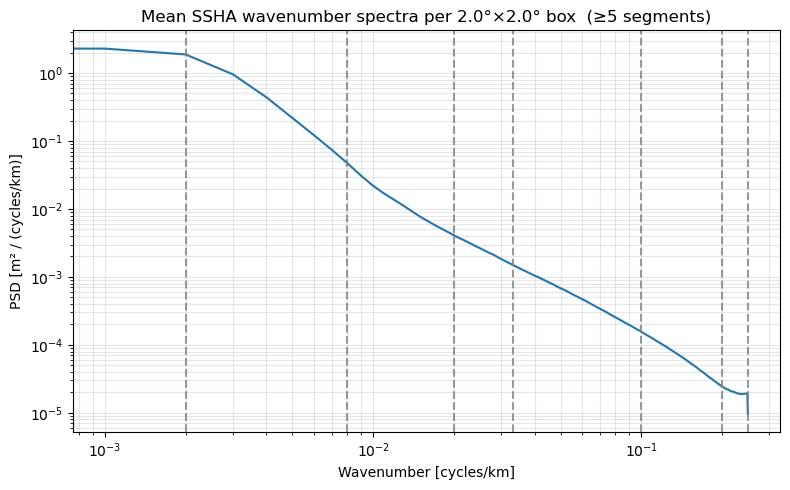

In [18]:
#Defining wavelengths of interest (very naive version)
MIN_SEGMENTS_PER_BOX = 5

mean_psd = ds_boxes.mean_psd.mean('box')
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(mean_psd["wavenumber"], mean_psd)

# Reference slopes
if False:
    k_ref = good_boxes["wavenumber"].values[2:]
    psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)
if True:
    for line in [1/500,1/125,1/50,1/30,1/10,1/5,1/4]:
        ax.axvline(line,c='grey',ls='--',alpha=0.8)
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_array([])
#plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
#ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

2850 boxes with ≥ 5 segments


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_123/3729990910.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


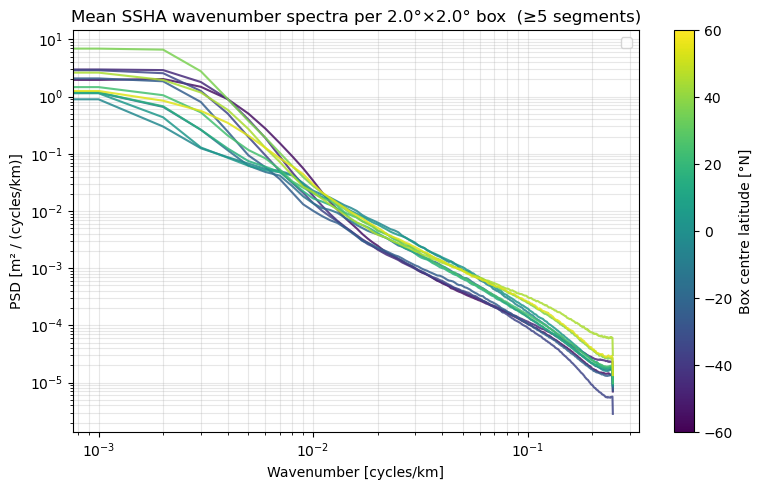

In [19]:
MIN_SEGMENTS_PER_BOX = 5
LAT_BIN_EDGES = np.arange(-60, 61, 10)  # adjust to the pass's latitude range

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

binned = good_boxes.groupby_bins("lat_center", LAT_BIN_EDGES).mean()
lat_vals = binned["lat_center_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

box=binned

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(box.sizes["lat_center_bins"]):
    lat_box = box.isel(lat_center_bins = i)
    ax.loglog(lat_box["wavenumber"], lat_box["mean_psd"],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
if False:
    k_ref = good_boxes["wavenumber"].values[2:]
    psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
    k0    = k_ref[0]
    for exp, ls in ((-2, "--"), (-11/3, ":"),(-5,"+-")):
        lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
        ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()


## 8. Save and shut down

In [20]:
save_dir = DATA_DIR+'diags_2024/'
ds_segments.to_netcdf(save_dir+'swot_segments2D_1000km_demean.nc',mode='w')
#ds_boxes.to_netcdf(save_dir+'swot_box_spectra_1000km_2deg_demean.nc',mode='w')

In [21]:
# Shut down the cluster when done.
client.close()
cluster.close()